In [12]:
##Dat 9
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

sns.set_style("darkgrid")
print("✅ Imports done!")

✅ Imports done!


In [13]:
# Cell 2 — Load model and data
with open('../models/xgb_fraud_model.pkl', 'rb') as f:
    model = pickle.load(f)

X_test = pd.read_csv('../data/splits/X_test.csv')
y_test = pd.read_csv('../data/splits/y_test.csv').squeeze()

# Get fraud probabilities
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_default = model.predict(X_test)  # default threshold=0.5

print("✅ Model and data loaded!")
print(f"\nTest samples: {len(X_test):,}")
print(f"Actual fraud cases: {y_test.sum()}")
print(f"\nWith default threshold (0.5):")
print(f"Predicted fraud: {y_pred_default.sum()}")

✅ Model and data loaded!

Test samples: 56,962
Actual fraud cases: 98

With default threshold (0.5):
Predicted fraud: 96


In [14]:
# Cell 3 — What is threshold?
print("""
=== WHAT IS A THRESHOLD? ===

Your model outputs a PROBABILITY for each transaction:

Transaction A → Fraud probability = 0.95  → clearly fraud
Transaction B → Fraud probability = 0.60  → probably fraud
Transaction C → Fraud probability = 0.45  → probably legit
Transaction D → Fraud probability = 0.02  → clearly legit

DEFAULT threshold = 0.5:
→ probability >= 0.5 = FRAUD
→ probability <  0.5 = LEGIT

But 0.5 is not always the best choice!

Lower threshold (e.g. 0.3):        Higher threshold (e.g. 0.7):
────────────────────────────        ────────────────────────────
Flags more transactions             Flags fewer transactions
Higher Recall (catch more fraud)    Higher Precision (fewer alarms)
Lower Precision (more false alarms) Lower Recall (miss some fraud)

For fraud detection:
→ Banks want HIGH RECALL (catch every fraud possible)
→ Payment apps want BALANCE (don't annoy customers)
→ You choose based on BUSINESS NEED
""")


=== WHAT IS A THRESHOLD? ===

Your model outputs a PROBABILITY for each transaction:

Transaction A → Fraud probability = 0.95  → clearly fraud
Transaction B → Fraud probability = 0.60  → probably fraud
Transaction C → Fraud probability = 0.45  → probably legit
Transaction D → Fraud probability = 0.02  → clearly legit

DEFAULT threshold = 0.5:
→ probability >= 0.5 = FRAUD
→ probability <  0.5 = LEGIT

But 0.5 is not always the best choice!

Lower threshold (e.g. 0.3):        Higher threshold (e.g. 0.7):
────────────────────────────        ────────────────────────────
Flags more transactions             Flags fewer transactions
Higher Recall (catch more fraud)    Higher Precision (fewer alarms)
Lower Precision (more false alarms) Lower Recall (miss some fraud)

For fraud detection:
→ Banks want HIGH RECALL (catch every fraud possible)
→ Payment apps want BALANCE (don't annoy customers)
→ You choose based on BUSINESS NEED



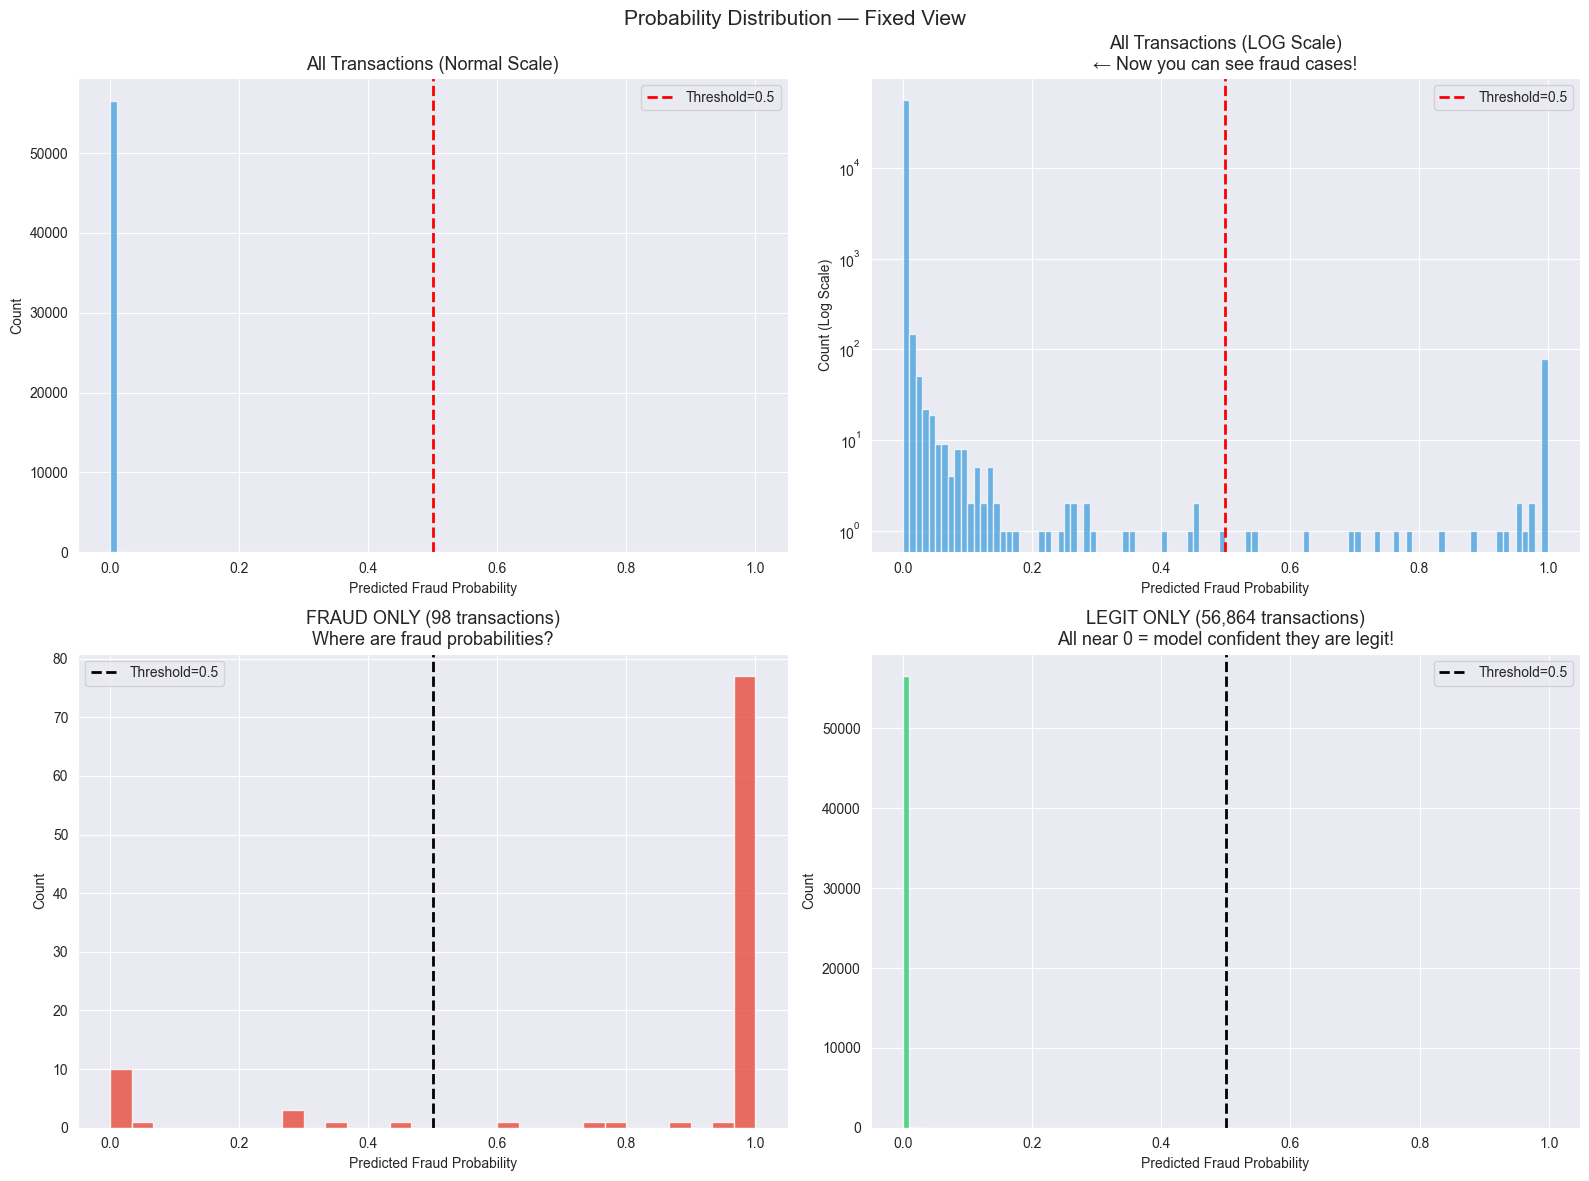

=== FRAUD PROBABILITY STATS ===

Fraud transactions (98):
  Min probability:  0.0000
  Max probability:  1.0000
  Mean probability: 0.8426
  Above 0.5:        82
  Below 0.5:        16 ← missed!

Legit transactions (56,864):
  Min probability:  0.0000
  Max probability:  0.9983
  Mean probability: 0.0006
  Above 0.5:        14 ← false alarms


In [15]:
# Cell 4 — Fixed probability distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: All transactions (log scale to see both)
axes[0][0].hist(y_prob, bins=100,
                color='#3498db', alpha=0.7)
axes[0][0].axvline(x=0.5, color='red', linestyle='--',
                   linewidth=2, label='Threshold=0.5')
axes[0][0].set_title('All Transactions (Normal Scale)',
                     fontsize=13)
axes[0][0].set_xlabel('Predicted Fraud Probability')
axes[0][0].set_ylabel('Count')
axes[0][0].legend()

# Plot 2: Log scale Y axis — NOW you can see fraud!
axes[0][1].hist(y_prob, bins=100,
                color='#3498db', alpha=0.7)
axes[0][1].axvline(x=0.5, color='red', linestyle='--',
                   linewidth=2, label='Threshold=0.5')
axes[0][1].set_yscale('log')   # ← KEY FIX
axes[0][1].set_title('All Transactions (LOG Scale)\n'
                     '← Now you can see fraud cases!',
                     fontsize=13)
axes[0][1].set_xlabel('Predicted Fraud Probability')
axes[0][1].set_ylabel('Count (Log Scale)')
axes[0][1].legend()

# Plot 3: ONLY fraud transactions
fraud_probs = y_prob[y_test == 1]
axes[1][0].hist(fraud_probs, bins=30,
                color='#e74c3c', alpha=0.8)
axes[1][0].axvline(x=0.5, color='black', linestyle='--',
                   linewidth=2, label='Threshold=0.5')
axes[1][0].set_title(f'FRAUD ONLY ({len(fraud_probs)} transactions)\n'
                     'Where are fraud probabilities?',
                     fontsize=13)
axes[1][0].set_xlabel('Predicted Fraud Probability')
axes[1][0].set_ylabel('Count')
axes[1][0].legend()

# Plot 4: ONLY legit transactions
legit_probs = y_prob[y_test == 0]
axes[1][1].hist(legit_probs, bins=100,
                color='#2ecc71', alpha=0.8)
axes[1][1].axvline(x=0.5, color='black', linestyle='--',
                   linewidth=2, label='Threshold=0.5')
axes[1][1].set_title(f'LEGIT ONLY ({len(legit_probs):,} transactions)\n'
                     'All near 0 = model confident they are legit!',
                     fontsize=13)
axes[1][1].set_xlabel('Predicted Fraud Probability')
axes[1][1].set_ylabel('Count')
axes[1][1].legend()

plt.suptitle('Probability Distribution — Fixed View',
             fontsize=15)
plt.tight_layout()
plt.savefig('../data/probability_distribution_fixed.png')
plt.show()

# Print actual probability stats
print("=== FRAUD PROBABILITY STATS ===")
print(f"\nFraud transactions ({len(fraud_probs)}):")
print(f"  Min probability:  {fraud_probs.min():.4f}")
print(f"  Max probability:  {fraud_probs.max():.4f}")
print(f"  Mean probability: {fraud_probs.mean():.4f}")
print(f"  Above 0.5:        {(fraud_probs >= 0.5).sum()}")
print(f"  Below 0.5:        {(fraud_probs < 0.5).sum()} ← missed!")

print(f"\nLegit transactions ({len(legit_probs):,}):")
print(f"  Min probability:  {legit_probs.min():.4f}")
print(f"  Max probability:  {legit_probs.max():.4f}")
print(f"  Mean probability: {legit_probs.mean():.4f}")
print(f"  Above 0.5:        {(legit_probs >= 0.5).sum()} ← false alarms")

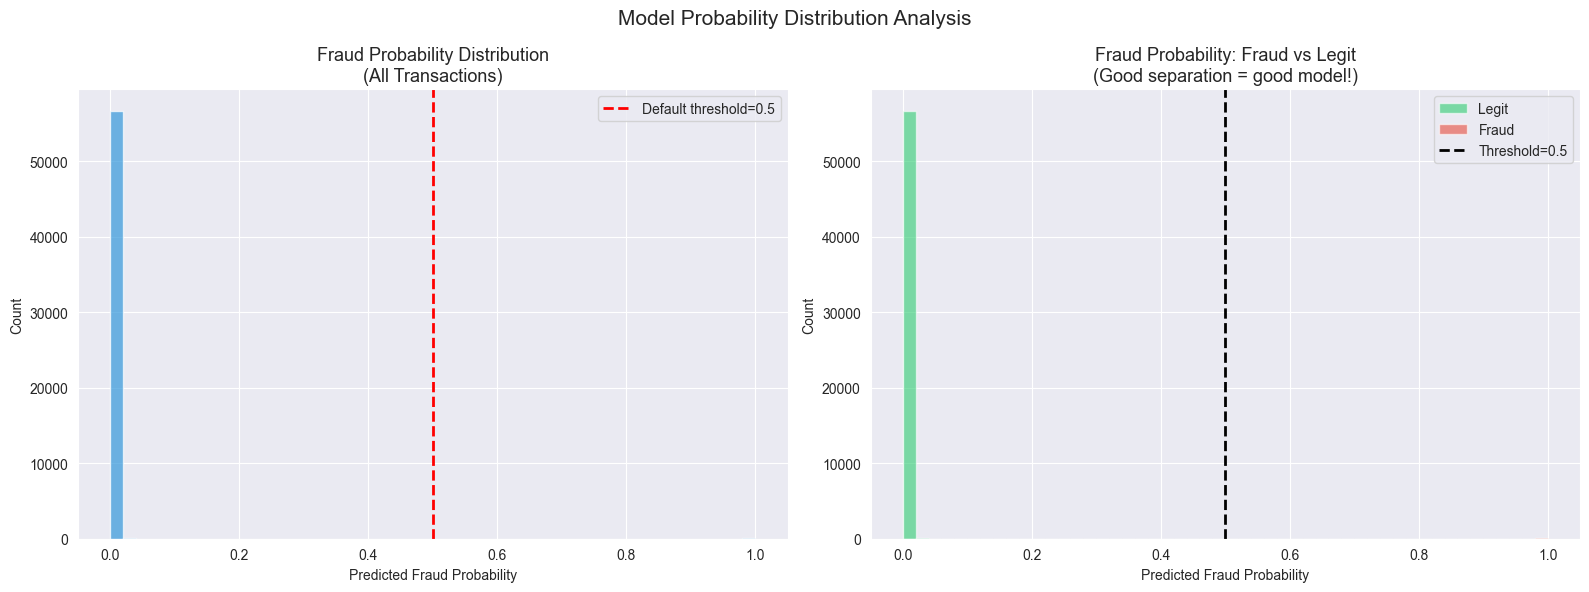

In [16]:
# Cell 4 — See probability distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All transactions
axes[0].hist(y_prob, bins=50,
             color='#3498db', alpha=0.7)
axes[0].axvline(x=0.5, color='red', linestyle='--',
                linewidth=2, label='Default threshold=0.5')
axes[0].set_title('Fraud Probability Distribution\n(All Transactions)',
                  fontsize=13)
axes[0].set_xlabel('Predicted Fraud Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# Separate fraud vs legit
fraud_probs = y_prob[y_test == 1]
legit_probs = y_prob[y_test == 0]

axes[1].hist(legit_probs, bins=50, alpha=0.6,
             color='#2ecc71', label='Legit')
axes[1].hist(fraud_probs, bins=50, alpha=0.6,
             color='#e74c3c', label='Fraud')
axes[1].axvline(x=0.5, color='black', linestyle='--',
                linewidth=2, label='Threshold=0.5')
axes[1].set_title('Fraud Probability: Fraud vs Legit\n'
                  '(Good separation = good model!)',
                  fontsize=13)
axes[1].set_xlabel('Predicted Fraud Probability')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Model Probability Distribution Analysis',
             fontsize=15)
plt.tight_layout()
plt.savefig('../data/probability_distribution.png')
plt.show()

In [17]:
# Cell 5 — Calculate metrics at every threshold
thresholds = np.arange(0.01, 1.0, 0.01)

precisions = []
recalls = []
f1_scores = []
fraud_caught = []
false_alarms = []

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)

    if y_pred_thresh.sum() == 0:
        precisions.append(0)
        recalls.append(0)
        f1_scores.append(0)
        fraud_caught.append(0)
        false_alarms.append(0)
        continue

    precisions.append(precision_score(
        y_test, y_pred_thresh, zero_division=0))
    recalls.append(recall_score(
        y_test, y_pred_thresh, zero_division=0))
    f1_scores.append(f1_score(
        y_test, y_pred_thresh, zero_division=0))

    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()
    fraud_caught.append(tp)
    false_alarms.append(fp)

results_df = pd.DataFrame({
    'threshold': thresholds,
    'precision': precisions,
    'recall': recalls,
    'f1': f1_scores,
    'fraud_caught': fraud_caught,
    'false_alarms': false_alarms
})

print("✅ Threshold analysis complete!")
print(f"\nTotal actual fraud cases: {y_test.sum()}")
print(f"\nSample results:")
print(results_df[results_df['threshold'].isin(
    [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
)][['threshold', 'precision', 'recall',
    'f1', 'fraud_caught', 'false_alarms']].to_string(index=False))

✅ Threshold analysis complete!

Total actual fraud cases: 98

Sample results:
 threshold  precision   recall       f1  fraud_caught  false_alarms
       0.2   0.769912 0.887755 0.824645            87            26
       0.3   0.815534 0.857143 0.835821            84            19
       0.4   0.821782 0.846939 0.834171            83            18
       0.5   0.854167 0.836735 0.845361            82            14
       0.6   0.872340 0.836735 0.854167            82            12
       0.8   0.897727 0.806122 0.849462            79             9
       0.9   0.906977 0.795918 0.847826            78             8


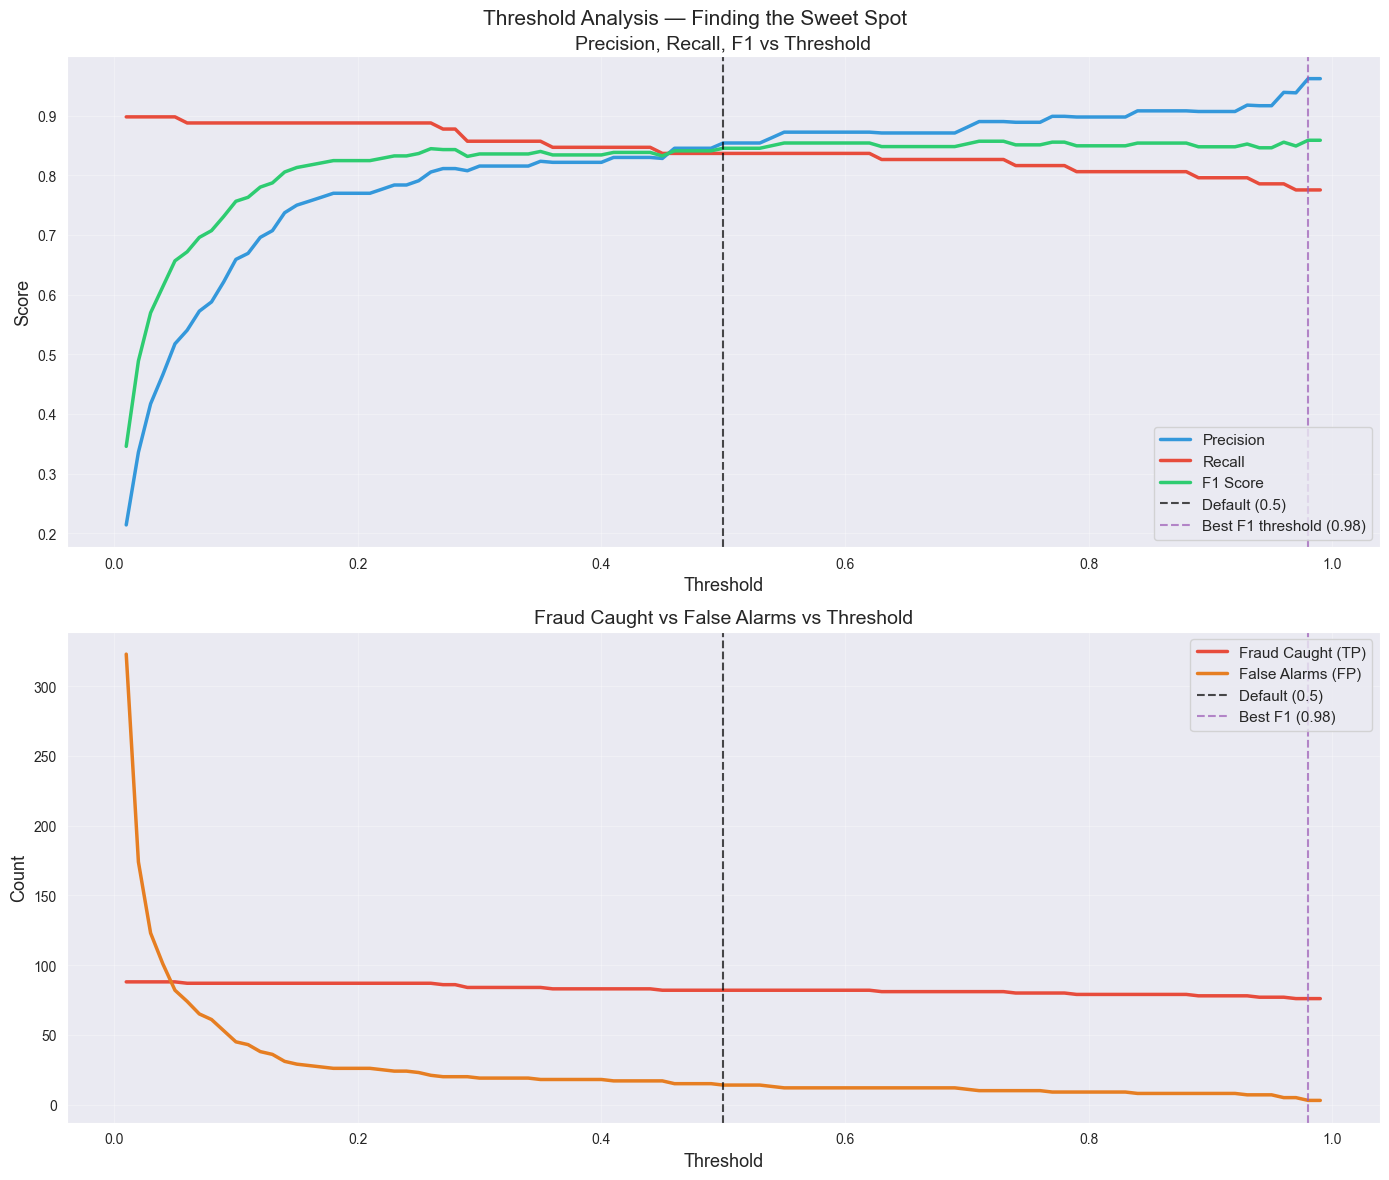


✅ Best F1 threshold: 0.98
   F1 at best threshold: 0.8588


In [18]:
# Cell 6 — Plot Precision, Recall, F1 vs Threshold
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Metrics vs Threshold
axes[0].plot(results_df['threshold'],
             results_df['precision'],
             color='#3498db', linewidth=2.5,
             label='Precision')
axes[0].plot(results_df['threshold'],
             results_df['recall'],
             color='#e74c3c', linewidth=2.5,
             label='Recall')
axes[0].plot(results_df['threshold'],
             results_df['f1'],
             color='#2ecc71', linewidth=2.5,
             label='F1 Score')

# Mark default threshold
axes[0].axvline(x=0.5, color='black', linestyle='--',
                alpha=0.7, label='Default (0.5)')

# Mark best F1 threshold
best_f1_idx = results_df['f1'].idxmax()
best_f1_thresh = results_df.loc[best_f1_idx, 'threshold']
best_f1_val = results_df.loc[best_f1_idx, 'f1']
axes[0].axvline(x=best_f1_thresh, color='#9b59b6',
                linestyle='--', alpha=0.7,
                label=f'Best F1 threshold ({best_f1_thresh:.2f})')

axes[0].set_xlabel('Threshold', fontsize=13)
axes[0].set_ylabel('Score', fontsize=13)
axes[0].set_title('Precision, Recall, F1 vs Threshold',
                  fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Fraud caught vs False alarms
axes[1].plot(results_df['threshold'],
             results_df['fraud_caught'],
             color='#e74c3c', linewidth=2.5,
             label='Fraud Caught (TP)')
axes[1].plot(results_df['threshold'],
             results_df['false_alarms'],
             color='#e67e22', linewidth=2.5,
             label='False Alarms (FP)')

axes[1].axvline(x=0.5, color='black', linestyle='--',
                alpha=0.7, label='Default (0.5)')
axes[1].axvline(x=best_f1_thresh, color='#9b59b6',
                linestyle='--', alpha=0.7,
                label=f'Best F1 ({best_f1_thresh:.2f})')

axes[1].set_xlabel('Threshold', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_title('Fraud Caught vs False Alarms vs Threshold',
                  fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Threshold Analysis — Finding the Sweet Spot',
             fontsize=15)
plt.tight_layout()
plt.savefig('../data/threshold_analysis.png')
plt.show()

print(f"\n✅ Best F1 threshold: {best_f1_thresh:.2f}")
print(f"   F1 at best threshold: {best_f1_val:.4f}")

In [ ]:
### mathematically the best threshold value is when the f1 score is high 


In [19]:
# Cell 7 — Find 3 optimal thresholds

# 1. Best F1 threshold (balance precision and recall)
best_f1_idx = results_df['f1'].idxmax()
best_f1_thresh = results_df.loc[best_f1_idx, 'threshold']

# 2. High recall threshold (catch 95%+ of fraud)
total_fraud = y_test.sum()
high_recall_thresh = results_df[
    results_df['recall'] >= 0.95
]['threshold'].max()

# 3. High precision threshold (precision > 0.90)
high_prec_thresh = results_df[
    results_df['precision'] >= 0.90
]['threshold'].min()

print("=" * 55)
print("3 OPTIMAL THRESHOLDS FOR DIFFERENT BUSINESS NEEDS")
print("=" * 55)

for thresh, name, use_case in [
    (0.5, "Default", "Standard (no tuning)"),
    (best_f1_thresh, "Best F1", "Balanced approach"),
    (high_recall_thresh, "High Recall", "Bank: catch every fraud"),
    (high_prec_thresh, "High Precision", "App: minimize false alarms")
]:
    y_pred_t = (y_prob >= thresh).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()

    print(f"\n📌 {name} (threshold={thresh:.2f}) — {use_case}")
    print(f"   Precision:    {p:.4f}")
    print(f"   Recall:       {r:.4f}")
    print(f"   F1:           {f:.4f}")
    print(f"   Fraud Caught: {tp} / {y_test.sum()}")
    print(f"   False Alarms: {fp:,}")

3 OPTIMAL THRESHOLDS FOR DIFFERENT BUSINESS NEEDS

📌 Default (threshold=0.50) — Standard (no tuning)
   Precision:    0.8542
   Recall:       0.8367
   F1:           0.8454
   Fraud Caught: 82 / 98
   False Alarms: 14

📌 Best F1 (threshold=0.98) — Balanced approach
   Precision:    0.9620
   Recall:       0.7755
   F1:           0.8588
   Fraud Caught: 76 / 98
   False Alarms: 3

📌 High Recall (threshold=nan) — Bank: catch every fraud
   Precision:    0.0000
   Recall:       0.0000
   F1:           0.0000
   Fraud Caught: 0 / 98
   False Alarms: 0

📌 High Precision (threshold=0.84) — App: minimize false alarms
   Precision:    0.9080
   Recall:       0.8061
   F1:           0.8541
   Fraud Caught: 79 / 98
   False Alarms: 8


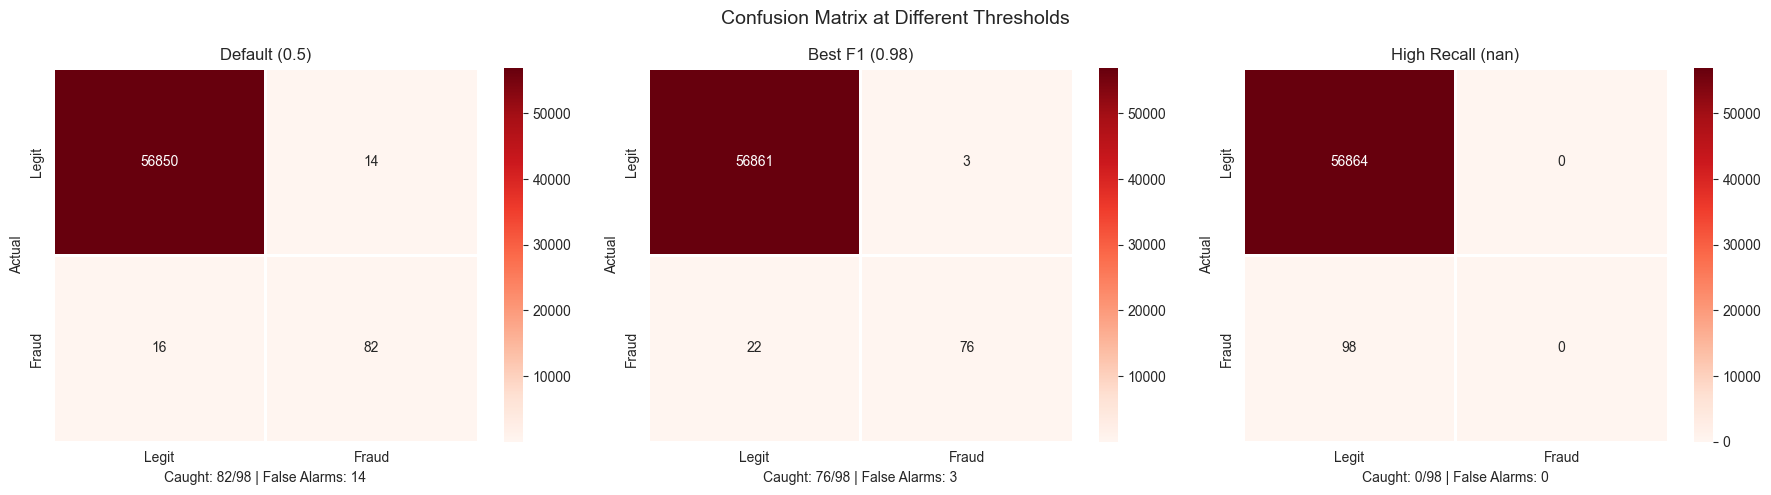

In [20]:
# Cell 8 — Side by side confusion matrices
thresholds_to_show = [
    (0.5, "Default (0.5)"),
    (best_f1_thresh, f"Best F1 ({best_f1_thresh:.2f})"),
    (high_recall_thresh, f"High Recall ({high_recall_thresh:.2f})")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (thresh, title) in enumerate(thresholds_to_show):
    y_pred_t = (y_prob >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)

    sns.heatmap(cm_t, annot=True, fmt='d',
                cmap='Reds',
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'],
                ax=axes[i], linewidths=2)
    axes[i].set_title(f'{title}', fontsize=12)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

    tn, fp, fn, tp = cm_t.ravel()
    axes[i].set_xlabel(
        f'Caught: {tp}/{y_test.sum()} | False Alarms: {fp:,}',
        fontsize=10
    )

plt.suptitle('Confusion Matrix at Different Thresholds',
             fontsize=14)
plt.tight_layout()
plt.savefig('../data/threshold_confusion_matrices.png')
plt.show()

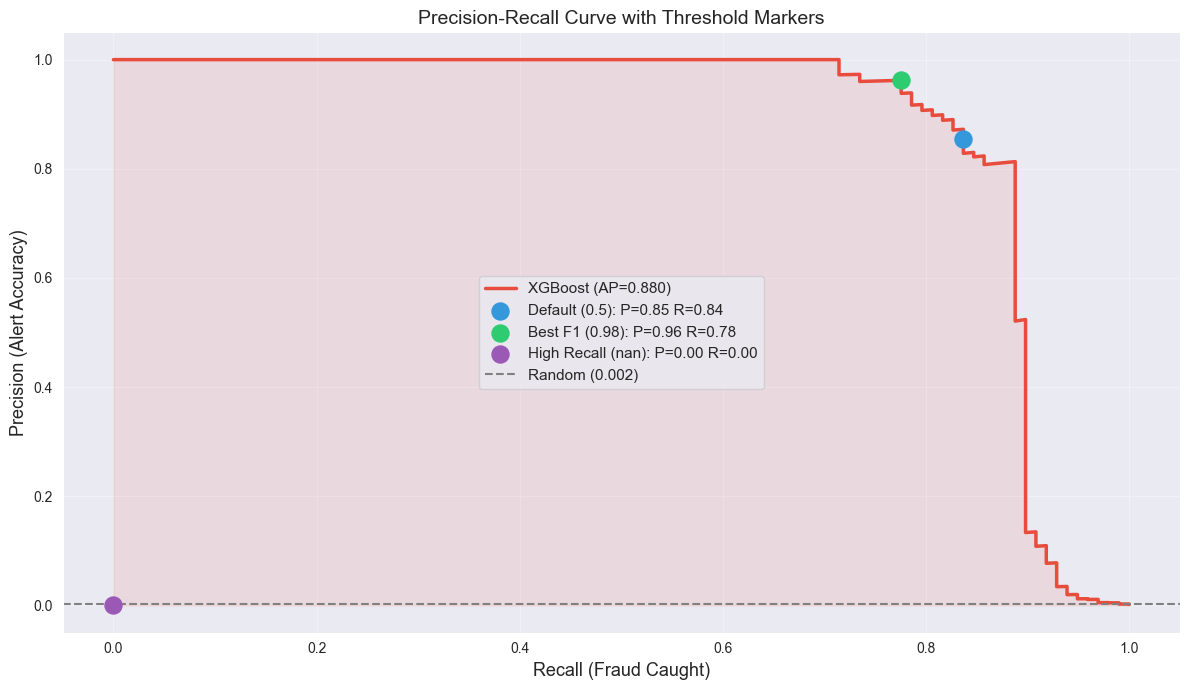

✅ Average Precision: 0.8800


In [21]:
# Cell 9 — Detailed PR Curve
precision_curve, recall_curve, pr_thresholds = \
    precision_recall_curve(y_test, y_prob)

avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(12, 7))

# Main curve
plt.plot(recall_curve, precision_curve,
         color='#e74c3c', linewidth=2.5,
         label=f'XGBoost (AP={avg_precision:.3f})')

# Mark our 3 thresholds on the curve
for thresh, name, color in [
    (0.5, 'Default (0.5)', '#3498db'),
    (best_f1_thresh, f'Best F1 ({best_f1_thresh:.2f})', '#2ecc71'),
    (high_recall_thresh,
     f'High Recall ({high_recall_thresh:.2f})', '#9b59b6')
]:
    y_pred_t = (y_prob >= thresh).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    plt.scatter(r, p, s=150, color=color,
                zorder=5, label=f'{name}: P={p:.2f} R={r:.2f}')

# Random baseline
baseline_val = y_test.sum() / len(y_test)
plt.axhline(y=baseline_val, color='gray',
            linestyle='--', label=f'Random ({baseline_val:.3f})')

plt.xlabel('Recall (Fraud Caught)', fontsize=13)
plt.ylabel('Precision (Alert Accuracy)', fontsize=13)
plt.title('Precision-Recall Curve with Threshold Markers',
          fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.fill_between(recall_curve, precision_curve,
                 alpha=0.1, color='#e74c3c')

plt.tight_layout()
plt.savefig('../data/pr_curve_detailed.png')
plt.show()

print(f"✅ Average Precision: {avg_precision:.4f}")

In [22]:
# Cell 10 — Business impact calculation
print("=" * 60)
print("BUSINESS IMPACT ANALYSIS")
print("=" * 60)

# Assumptions (realistic for Indian market)
avg_fraud_amount = 5000      # ₹5,000 average fraud transaction
avg_investigation_cost = 200  # ₹200 cost to investigate false alarm

total_fraud = y_test.sum()

print(f"\nAssumptions:")
print(f"  Average fraud amount:       ₹{avg_fraud_amount:,}")
print(f"  Investigation cost (FP):    ₹{avg_investigation_cost:,}")
print(f"  Total fraud in test set:    {total_fraud}")

print("\n" + "=" * 60)

for thresh, name in [
    (0.5, "Default Threshold (0.5)"),
    (best_f1_thresh, f"Best F1 Threshold ({best_f1_thresh:.2f})"),
    (high_recall_thresh,
     f"High Recall Threshold ({high_recall_thresh:.2f})")
]:
    y_pred_t = (y_prob >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()

    fraud_saved = tp * avg_fraud_amount
    investigation_cost = fp * avg_investigation_cost
    net_benefit = fraud_saved - investigation_cost
    fraud_missed_cost = fn * avg_fraud_amount

    print(f"\n📌 {name}")
    print(f"   Fraud caught:           {tp} / {total_fraud}")
    print(f"   Fraud missed:           {fn}")
    print(f"   False alarms:           {fp:,}")
    print(f"   Money saved:            ₹{fraud_saved:,}")
    print(f"   Investigation cost:     ₹{investigation_cost:,}")
    print(f"   Fraud missed cost:      ₹{fraud_missed_cost:,}")
    print(f"   NET BENEFIT:            ₹{net_benefit:,}")

BUSINESS IMPACT ANALYSIS

Assumptions:
  Average fraud amount:       ₹5,000
  Investigation cost (FP):    ₹200
  Total fraud in test set:    98


📌 Default Threshold (0.5)
   Fraud caught:           82 / 98
   Fraud missed:           16
   False alarms:           14
   Money saved:            ₹410,000
   Investigation cost:     ₹2,800
   Fraud missed cost:      ₹80,000
   NET BENEFIT:            ₹407,200

📌 Best F1 Threshold (0.98)
   Fraud caught:           76 / 98
   Fraud missed:           22
   False alarms:           3
   Money saved:            ₹380,000
   Investigation cost:     ₹600
   Fraud missed cost:      ₹110,000
   NET BENEFIT:            ₹379,400

📌 High Recall Threshold (nan)
   Fraud caught:           0 / 98
   Fraud missed:           98
   False alarms:           0
   Money saved:            ₹0
   Investigation cost:     ₹0
   Fraud missed cost:      ₹490,000
   NET BENEFIT:            ₹0


In [23]:
# Cell 11 — Pick and save final threshold
print("=== CHOOSING FINAL THRESHOLD ===")
print("""
For this project we choose the BEST F1 THRESHOLD because:
1. It balances precision and recall optimally
2. Works well for general fraud detection
3. Not too many false alarms
4. Not missing too many frauds

In production:
- Bank → use HIGH RECALL threshold
- Payment app → use HIGH PRECISION threshold
- General system → use BEST F1 threshold ✅
""")

final_threshold = best_f1_thresh

# Final results with chosen threshold
y_pred_final = (y_prob >= final_threshold).astype(int)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_auc = roc_auc_score(y_test, y_prob)

print(f"✅ Final threshold chosen: {final_threshold:.2f}")
print(f"\n=== FINAL MODEL RESULTS ===")
print(f"AUC-ROC:   {final_auc:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1:        {final_f1:.4f}")

# Save threshold
threshold_config = {
    'final_threshold': float(final_threshold),
    'best_f1_threshold': float(best_f1_thresh),
    'high_recall_threshold': float(high_recall_thresh),
    'high_precision_threshold': float(high_prec_thresh),
    'final_metrics': {
        'auc_roc': round(final_auc, 4),
        'precision': round(final_precision, 4),
        'recall': round(final_recall, 4),
        'f1': round(final_f1, 4)
    }
}

with open('../models/threshold_config.json', 'w') as f:
    json.dump(threshold_config, f, indent=2)

print(f"\n✅ Threshold config saved!")

=== CHOOSING FINAL THRESHOLD ===

For this project we choose the BEST F1 THRESHOLD because:
1. It balances precision and recall optimally
2. Works well for general fraud detection
3. Not too many false alarms
4. Not missing too many frauds

In production:
- Bank → use HIGH RECALL threshold
- Payment app → use HIGH PRECISION threshold
- General system → use BEST F1 threshold ✅

✅ Final threshold chosen: 0.98

=== FINAL MODEL RESULTS ===
AUC-ROC:   0.9817
Precision: 0.9620
Recall:    0.7755
F1:        0.8588

✅ Threshold config saved!
